<div style="background: linear-gradient(135deg, #1B2A4A 0%, #0D7C66 100%); padding: 40px; border-radius: 12px; margin-bottom: 20px;">
<h1 style="color: white; font-family: Georgia, serif; margin: 0; font-size: 2.4em;">
🛒 Notebook 1: Data Cartography
</h1>
<p style="color: #C9932F; font-size: 1.3em; margin-top: 10px; font-family: Calibri, sans-serif;">
Brazilian E-Commerce (Olist) — Mapping the Data Universe
</p>
<p style="color: #B0D0D0; font-size: 0.95em; margin-top: 8px;">
E-Commerce Analytics · MBA Advanced Analytics · 2025–26
</p>
</div>

<div style="background: #FFFFFF; border: 2px solid #0D7C66; padding: 20px 28px; border-radius: 10px; margin: 10px 0 20px 0;">
<h3 style="color: #1B2A4A; margin-top: 0;">🗺️ Notebook Roadmap</h3>
<ol style="color: #333; font-size: 1.05em; line-height: 1.9;">
<li><strong>Environment Setup</strong> — Libraries and display configuration</li>
<li><strong>Load All 9 Tables</strong> — Shape, size and granularity of each file</li>
<li><strong>Star Schema</strong> — How the 9 tables connect and join key validation</li>
<li><strong>Data Quality Audit</strong> — Nulls, dtypes, anomalies per table</li>
<li><strong>Target Variable Engineering</strong> — Build <code>bad_experience</code> binary flag</li>
<li><strong>Build the Master Joined Table</strong> — One row per order with all features</li>
<li><strong>KPI Engineering</strong> — Derive delivery delay, freight ratio, order value, etc.</li>
<li><strong>Summary Statistics Dashboard</strong> — Full statistical profile of the master table</li>
</ol>
</div>

> **Dataset:** Brazilian E-Commerce Public Dataset by Olist · Kaggle  
> **Domain:** E-commerce orders, logistics, payments, reviews · 2016–2018  
> **9 CSV files · ~1.55 million total rows**


<div style="background: linear-gradient(90deg, #1B2A4A, #0D7C66); padding: 14px 24px; border-radius: 8px; margin: 30px 0 12px 0;">
<h2 style="color: white; margin: 0; font-family: Georgia, serif;">Part 1: Environment Setup</h2>
</div>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:,.2f}'.format)
pd.set_option('display.max_colwidth', 60)
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.figsize': (12, 6), 'figure.dpi': 120,
    'axes.titlesize': 14, 'axes.labelsize': 12,
    'axes.titleweight': 'bold', 'font.size': 11,
    'axes.spines.top': False, 'axes.spines.right': False,
})

NAVY   = '#1B2A4A'
TEAL   = '#0D7C66'
GOLD   = '#C9932F'
CORAL  = '#D95F4B'
PURPLE = '#6B5EA8'
BLUE   = '#3A8FB5'
PALETTE = [NAVY, TEAL, GOLD, CORAL, PURPLE, BLUE]
sns.set_palette(PALETTE)

print("✅ Environment ready!")


✅ Environment ready!


<div style="background: linear-gradient(90deg, #1B2A4A, #0D7C66); padding: 14px 24px; border-radius: 8px; margin: 30px 0 12px 0;">
<h2 style="color: white; margin: 0; font-family: Georgia, serif;">Part 2: Load All 9 Tables</h2>
<p style="color: #C9932F; margin: 4px 0 0 0; font-size: 1.05em;">Shape, memory, and granularity of every file</p>
</div>

<div style="background: #E8F4F1; border-left: 5px solid #0D7C66; padding: 16px 20px; border-radius: 6px; margin: 12px 0;">
<strong style="color: #1B2A4A;">🎯 Learning Objective</strong><br>
<span style="color: #333;">Load all 9 CSV files and understand what one row means in each table — called <strong>granularity</strong>. This is the most important concept to understand before joining any tables together.</span>
</div>

In [2]:
# ── UPDATE THIS PATH to your Dataset 3 folder ──
DATA_DIR = r'C:\Users\DevA\OneDrive\Desktop\All in one - Desktop Files\MBA\Q8\AI ML\Dataset 3'

files = {
    'orders'               : 'olist_orders_dataset.csv',
    'customers'            : 'olist_customers_dataset.csv',
    'order_items'          : 'olist_order_items_dataset.csv',
    'payments'             : 'olist_order_payments_dataset.csv',
    'reviews'              : 'olist_order_reviews_dataset.csv',
    'products'             : 'olist_products_dataset.csv',
    'sellers'              : 'olist_sellers_dataset.csv',
    'geolocation'          : 'olist_geolocation_dataset.csv',
    'category_translation' : 'product_category_name_translation.csv',
}

tables = {}
for name, fname in files.items():
    tables[name] = pd.read_csv(os.path.join(DATA_DIR, fname))

granularity = {
    'orders'               : '1 row = 1 order placed by a customer',
    'customers'            : '1 row = 1 customer (linked to one order)',
    'order_items'          : '1 row = 1 item within an order (orders can have multiple items)',
    'payments'             : '1 row = 1 payment transaction (orders can have multiple payment methods)',
    'reviews'              : '1 row = 1 review submitted for an order',
    'products'             : '1 row = 1 unique product listed on the platform',
    'sellers'              : '1 row = 1 seller registered on Olist',
    'geolocation'          : '1 row = 1 zip code coordinate record (multiple per zip code)',
    'category_translation' : '1 row = 1 product category (Portuguese to English name)',
}

print(f"{'Table':<25} {'Rows':>10} {'Cols':>6}  Granularity")
print("─" * 92)
for name, df in tables.items():
    print(f"{name:<25} {df.shape[0]:>10,} {df.shape[1]:>6}  {granularity[name]}")

total = sum(df.shape[0] for df in tables.values())
print(f"\n{'TOTAL ROWS':<25} {total:>10,}")


Table                           Rows   Cols  Granularity
────────────────────────────────────────────────────────────────────────────────────────────
orders                        99,441      8  1 row = 1 order placed by a customer
customers                     99,441      5  1 row = 1 customer (linked to one order)
order_items                  112,650      7  1 row = 1 item within an order (orders can have multiple items)
payments                     103,886      5  1 row = 1 payment transaction (orders can have multiple payment methods)
reviews                       99,224      7  1 row = 1 review submitted for an order
products                      32,951      9  1 row = 1 unique product listed on the platform
sellers                        3,095      4  1 row = 1 seller registered on Olist
geolocation                1,000,163      5  1 row = 1 zip code coordinate record (multiple per zip code)
category_translation              71      2  1 row = 1 product category (Portuguese to En

<div style="background: linear-gradient(90deg, #E0F4EF, #FDF6E8); border-left: 5px solid #0D7C66; border-right: 5px solid #C9932F; padding: 16px 20px; border-radius: 6px; margin: 12px 0;">
<strong style="color: #1B2A4A;">🧠 Key Insight — Fan-out Problem</strong><br>
<span style="color: #333;">
The <strong>orders</strong> table is the central fact table — every other table links to it via <code>order_id</code>.<br>
Notice that <strong>order_items</strong> has <em>more rows than orders</em> (112,650 vs 99,441) — some orders contain multiple products.<br>
<strong>Implication:</strong> when joining, we must first <em>aggregate</em> <code>order_items</code> and <code>payments</code> to the order level.
Joining them directly without aggregating first would multiply rows and corrupt all statistics — this is the <strong>fan-out problem</strong>.
</span>
</div>

<div style="background: linear-gradient(90deg, #1B2A4A, #0D7C66); padding: 14px 24px; border-radius: 8px; margin: 30px 0 12px 0;">
<h2 style="color: white; margin: 0; font-family: Georgia, serif;">Part 3: Star Schema & Join Key Validation</h2>
</div>

<div style="background: #FFFFFF; border: 2px solid #C9932F; padding: 18px 24px; border-radius: 10px; margin: 12px 0;">
<strong style="color: #1B2A4A;">📐 The Schema at a Glance</strong>
<pre style="color: #333; font-size: 0.95em; margin-top: 10px; line-height: 1.8;">
                    ┌─────────────┐
                    │  customers  │ ← customer_id
                    └──────┬──────┘
                           │
  ┌──────────┐    ┌────────┴────────┐    ┌──────────┐
  │ reviews  │←── │     orders      │───→│ payments │
  │(order_id)│    │  (fact table)   │    │(order_id)│
  └──────────┘    └────────┬────────┘    └──────────┘
                           │
                  ┌─────────┴─────────┐
                  │    order_items    │ ← order_id
                  └────────┬──────────┘
                     ┌─────┴──────┐
                     │            │
               ┌─────┴────┐ ┌────┴────────┐
               │ products │ │   sellers   │
               └─────┬────┘ └─────────────┘
                     │
         ┌───────────┴────────────┐
         │  category_translation  │
         └────────────────────────┘
  geolocation → links via zip_code_prefix from customers and sellers
</pre>
</div>

In [3]:
# ── Validate join keys — check for orphan records ──

checks = [
    ("Orders with valid customer_id",
     tables['orders']['customer_id'].isin(tables['customers']['customer_id']),
     len(tables['orders'])),

    ("Order items with valid order_id",
     tables['order_items']['order_id'].isin(tables['orders']['order_id']),
     len(tables['order_items'])),

    ("Reviews with valid order_id",
     tables['reviews']['order_id'].isin(tables['orders']['order_id']),
     len(tables['reviews'])),

    ("Orders that have at least one review",
     tables['orders']['order_id'].isin(tables['reviews']['order_id']),
     len(tables['orders'])),

    ("Orders that have a payment record",
     tables['orders']['order_id'].isin(tables['payments']['order_id']),
     len(tables['orders'])),

    ("Order items with a valid product",
     tables['order_items']['product_id'].isin(tables['products']['product_id']),
     len(tables['order_items'])),
]

print(f"{'Check':<45} {'Matched':>8} {'Total':>8}  {'Pct':>6}")
print("─" * 74)
for label, mask, total in checks:
    print(f"{label:<45} {mask.sum():>8,} {total:>8,}  {mask.mean():>6.1%}")


Check                                          Matched    Total     Pct
──────────────────────────────────────────────────────────────────────────
Orders with valid customer_id                   99,441   99,441  100.0%
Order items with valid order_id                112,650  112,650  100.0%
Reviews with valid order_id                     99,224   99,224  100.0%
Orders that have at least one review            98,673   99,441   99.2%
Orders that have a payment record               99,440   99,441  100.0%
Order items with a valid product               112,650  112,650  100.0%


<div style="background: linear-gradient(90deg, #1B2A4A, #0D7C66); padding: 14px 24px; border-radius: 8px; margin: 30px 0 12px 0;">
<h2 style="color: white; margin: 0; font-family: Georgia, serif;">Part 4: Data Quality Audit</h2>
<p style="color: #C9932F; margin: 4px 0 0 0; font-size: 1.05em;">Nulls, data types, and anomalies across every table</p>
</div>

✅ Datetime columns parsed


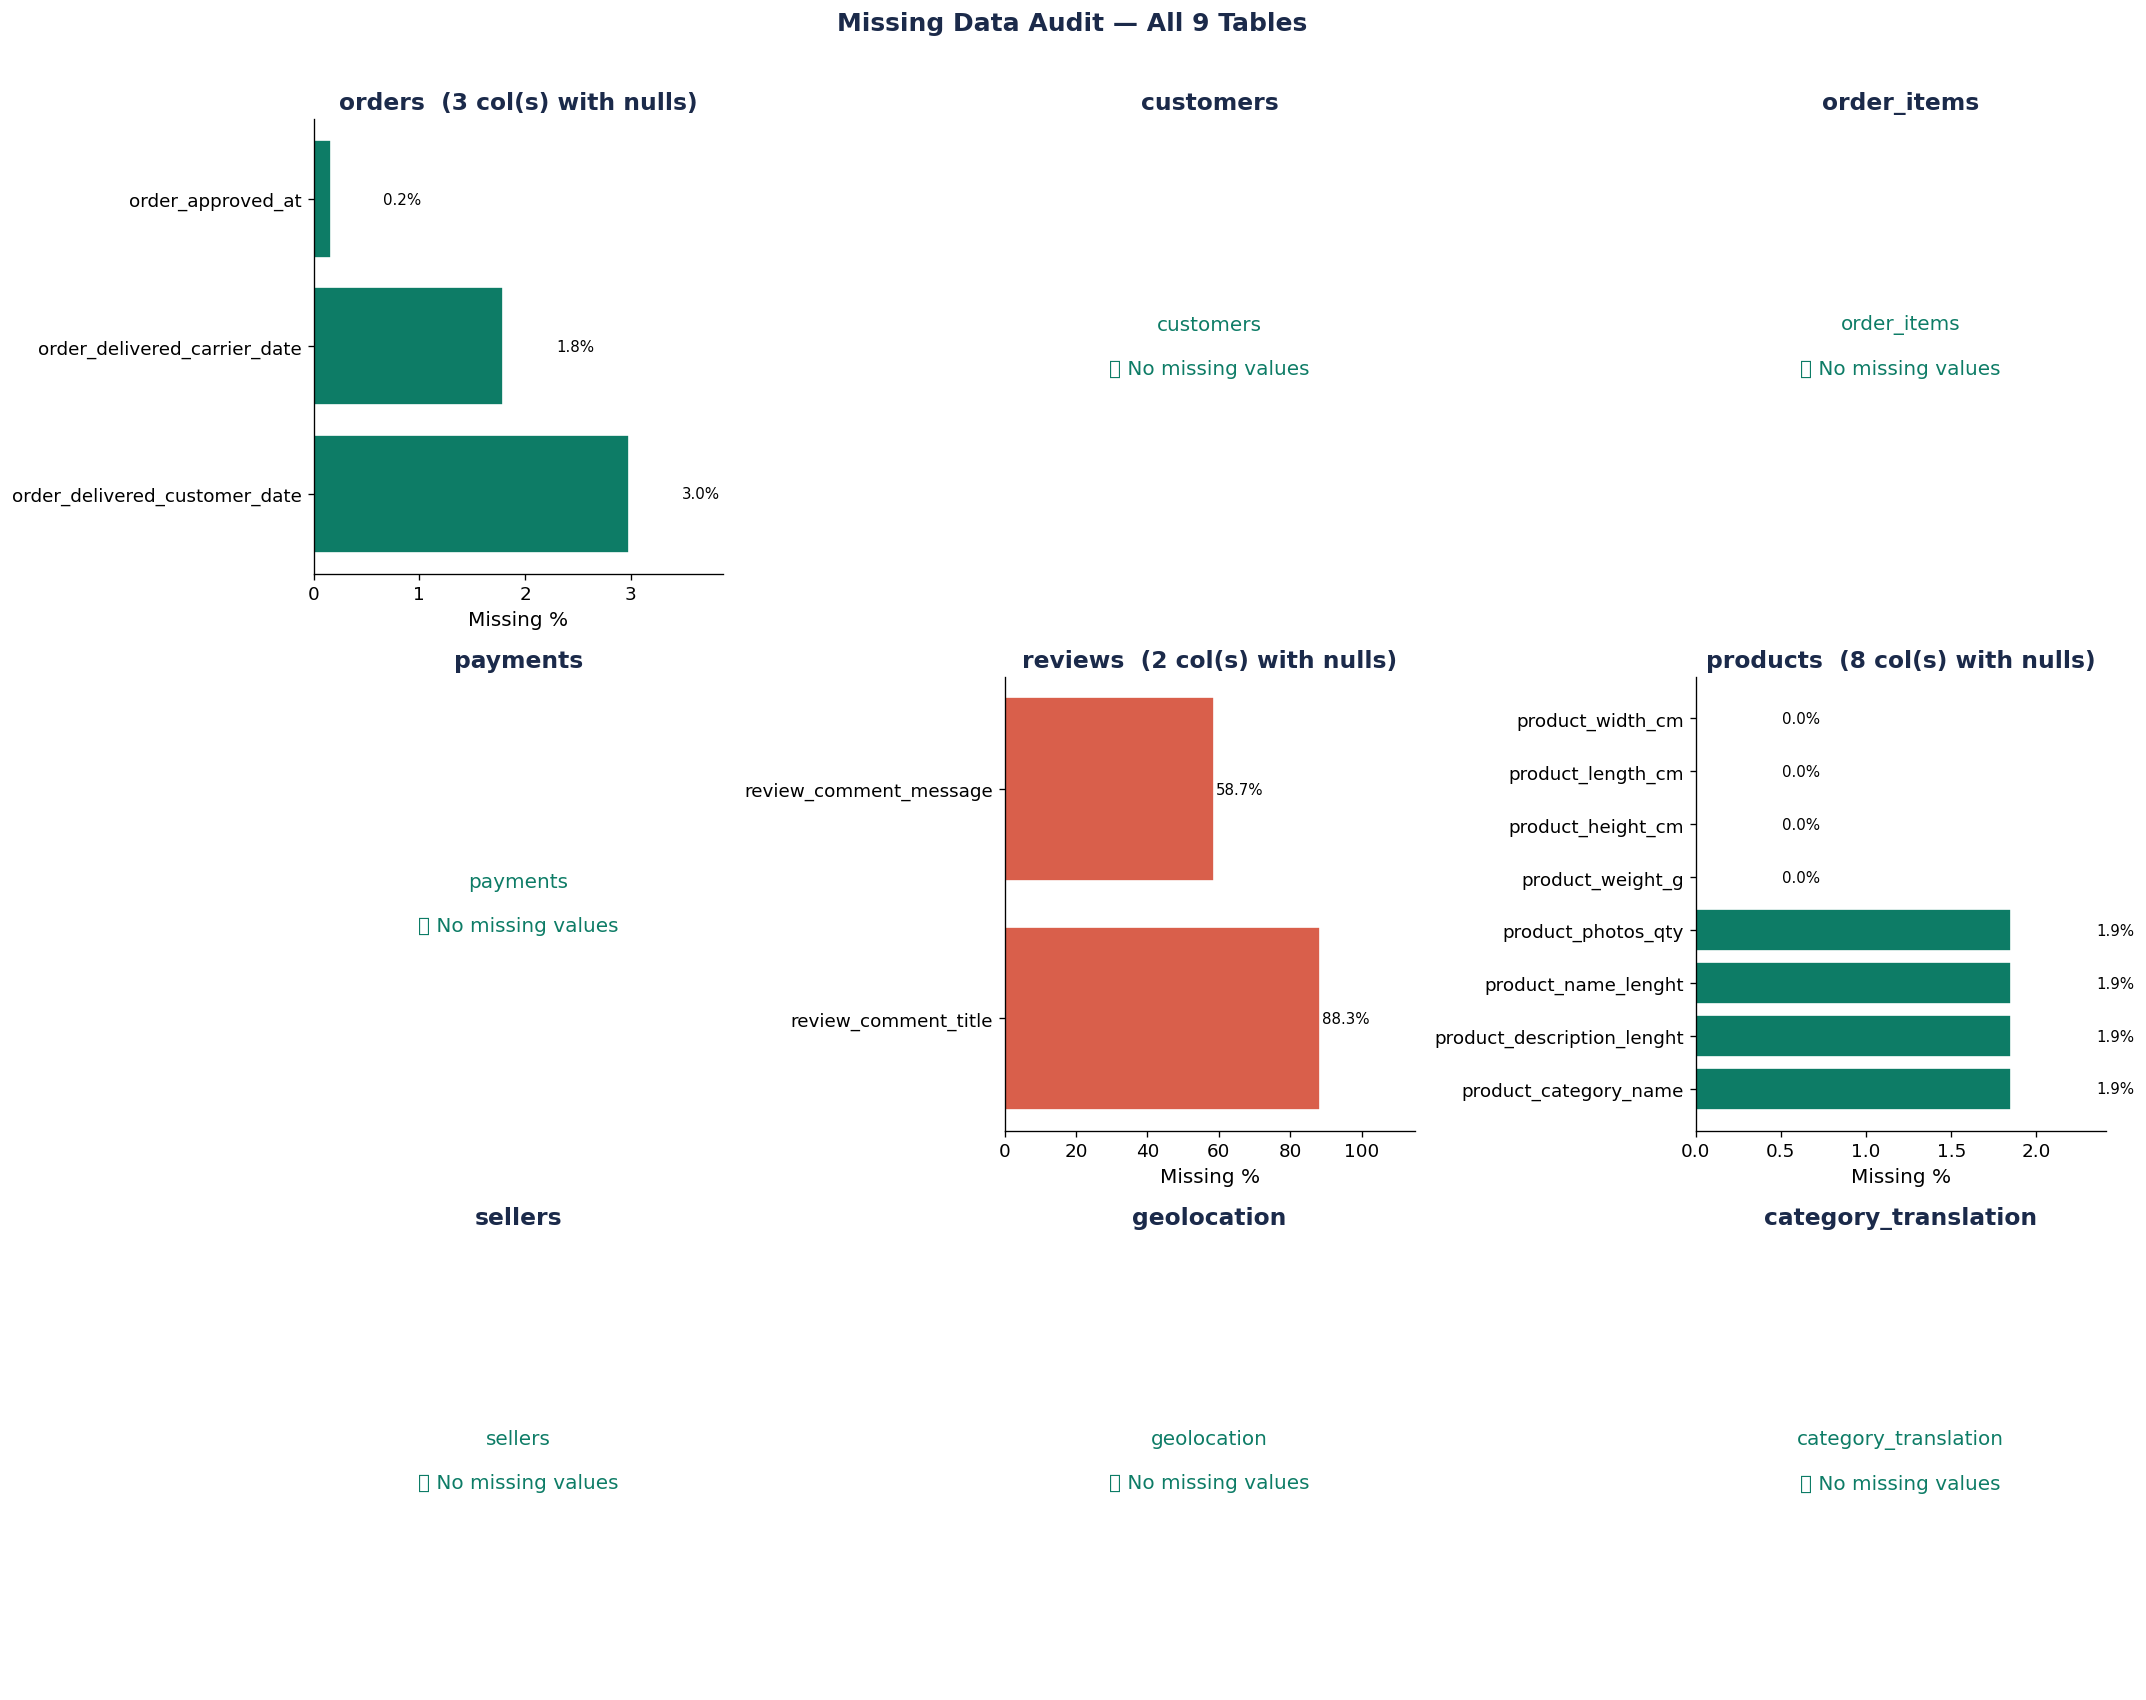

In [4]:
# ── Parse all datetime columns ──
dt_cols_orders = ['order_purchase_timestamp', 'order_approved_at',
                  'order_delivered_carrier_date', 'order_delivered_customer_date',
                  'order_estimated_delivery_date']
for col in dt_cols_orders:
    tables['orders'][col] = pd.to_datetime(tables['orders'][col])

tables['order_items']['shipping_limit_date']    = pd.to_datetime(tables['order_items']['shipping_limit_date'])
tables['reviews']['review_creation_date']       = pd.to_datetime(tables['reviews']['review_creation_date'])
tables['reviews']['review_answer_timestamp']    = pd.to_datetime(tables['reviews']['review_answer_timestamp'])

print("✅ Datetime columns parsed")

# ── Missingness heatmap across all 9 tables ──
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.ravel()

for i, (name, df) in enumerate(tables.items()):
    miss_pct = (df.isnull().mean() * 100).sort_values(ascending=False)
    miss_pct = miss_pct[miss_pct > 0]

    if len(miss_pct) == 0:
        axes[i].text(0.5, 0.5, f'{name}\n\n✅ No missing values',
                     ha='center', va='center', fontsize=12, color=TEAL,
                     transform=axes[i].transAxes)
        axes[i].set_title(name, color=NAVY, fontweight='bold')
        axes[i].axis('off')
    else:
        colors = [CORAL if v > 50 else GOLD if v > 10 else TEAL for v in miss_pct.values]
        axes[i].barh(miss_pct.index, miss_pct.values, color=colors, edgecolor='white')
        for j, (col, val) in enumerate(miss_pct.items()):
            axes[i].text(val + 0.5, j, f'{val:.1f}%', va='center', fontsize=9)
        axes[i].set_title(f'{name}  ({len(miss_pct)} col(s) with nulls)', color=NAVY, fontweight='bold')
        axes[i].set_xlabel('Missing %')
        axes[i].set_xlim(0, miss_pct.max() * 1.3)

plt.suptitle('Missing Data Audit — All 9 Tables', fontsize=15, color=NAVY, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


In [5]:
# ── Order status breakdown ──
print("Order Status Distribution:")
print("─" * 45)
status = tables['orders']['order_status'].value_counts()
for s, c in status.items():
    pct = c / len(tables['orders']) * 100
    bar = '█' * int(pct / 2)
    print(f"  {s:<20} {c:>7,}  ({pct:.1f}%)  {bar}")

print(f"\nDate range of orders:")
print(f"  Earliest purchase : {tables['orders']['order_purchase_timestamp'].min()}")
print(f"  Latest purchase   : {tables['orders']['order_purchase_timestamp'].max()}")


Order Status Distribution:
─────────────────────────────────────────────
  delivered             96,478  (97.0%)  ████████████████████████████████████████████████
  shipped                1,107  (1.1%)  
  canceled                 625  (0.6%)  
  unavailable              609  (0.6%)  
  invoiced                 314  (0.3%)  
  processing               301  (0.3%)  
  created                    5  (0.0%)  
  approved                   2  (0.0%)  

Date range of orders:
  Earliest purchase : 2016-09-04 21:15:19
  Latest purchase   : 2018-10-17 17:30:18


<div style="background: #FFF3CD; border-left: 5px solid #C9932F; padding: 16px 20px; border-radius: 6px; margin: 12px 0;">
<strong style="color: #C9932F;">⚠️ Important Quality Flags to Remember</strong><br>
<span style="color: #333;">
1. <strong>review_comment_title</strong>: 88.3% missing — normal, most customers skip the title field. Do not drop the row.<br>
2. <strong>review_comment_message</strong>: 58.7% missing — same reason. We will use <code>review_score</code> (numeric) instead of text.<br>
3. <strong>order_delivered_customer_date</strong>: Null for cancelled/undelivered orders — this is expected, not a data error.<br>
4. <strong>product_category_name</strong>: 1.9% missing in products — small enough to fill with 'unknown'.<br>
5. We will filter to <code>order_status = 'delivered'</code> for all analysis, since only delivered orders have meaningful delivery metrics.
</span>
</div>

<div style="background: linear-gradient(90deg, #1B2A4A, #0D7C66); padding: 14px 24px; border-radius: 8px; margin: 30px 0 12px 0;">
<h2 style="color: white; margin: 0; font-family: Georgia, serif;">Part 5: Target Variable Engineering</h2>
<p style="color: #C9932F; margin: 4px 0 0 0; font-size: 1.05em;">Defining what we want to predict</p>
</div>

<div style="background: #E8F4F1; border-left: 5px solid #0D7C66; padding: 16px 20px; border-radius: 6px; margin: 12px 0;">
<strong style="color: #1B2A4A;">🎯 Key Difference from a Given Dataset</strong><br>
<span style="color: #333;">
In supervised ML, sometimes the target (0/1 label) is given directly. Here, we must <strong>engineer our own target</strong> from the data.<br>
The business question is: <em>"What drives a poor customer experience?"</em><br><br>
We define: <code>bad_experience = 1</code> if <code>review_score ≤ 2</code> (1 or 2 stars), else <code>0</code>.
</span>
</div>

In [6]:
# Filter to delivered orders only
delivered = tables['orders'][tables['orders']['order_status'] == 'delivered'].copy()
print(f"Delivered orders : {len(delivered):,} out of {len(tables['orders']):,} total")

# Bring in review scores (deduplicated — one review per order)
reviews_dedup = (tables['reviews']
    .sort_values('review_creation_date')
    .drop_duplicates('order_id', keep='last')
    [['order_id', 'review_score']])

delivered = delivered.merge(reviews_dedup, on='order_id', how='left')

print(f"With a review    : {delivered['review_score'].notna().sum():,}  ({delivered['review_score'].notna().mean():.1%})")
print(f"Without review   : {delivered['review_score'].isna().sum():,}")

# ── Define target ──
delivered['bad_experience'] = (delivered['review_score'] <= 2).astype(int)
bad_rate = delivered['bad_experience'].mean()

# ── Score breakdown ──
score_counts = delivered['review_score'].value_counts().sort_index()
print(f"\nReview Score Distribution:")
print("─" * 50)
for score, count in score_counts.items():
    pct = count / delivered['review_score'].notna().sum() * 100
    bar = '█' * int(pct / 2)
    flag = '  ← BAD EXPERIENCE' if score <= 2 else ''
    print(f"  {score:.0f} star   {count:>7,}  ({pct:.1f}%)  {bar}{flag}")

print(f"\nBad Experience Rate (≤ 2 stars) : {bad_rate:.2%}")


Delivered orders : 96,478 out of 99,441 total
With a review    : 95,832  (99.3%)
Without review   : 646

Review Score Distribution:
──────────────────────────────────────────────────
  1 star     9,353  (9.8%)  ████  ← BAD EXPERIENCE
  2 star     2,920  (3.0%)  █  ← BAD EXPERIENCE
  3 star     7,917  (8.3%)  ████
  4 star    18,893  (19.7%)  █████████
  5 star    56,749  (59.2%)  █████████████████████████████

Bad Experience Rate (≤ 2 stars) : 12.72%


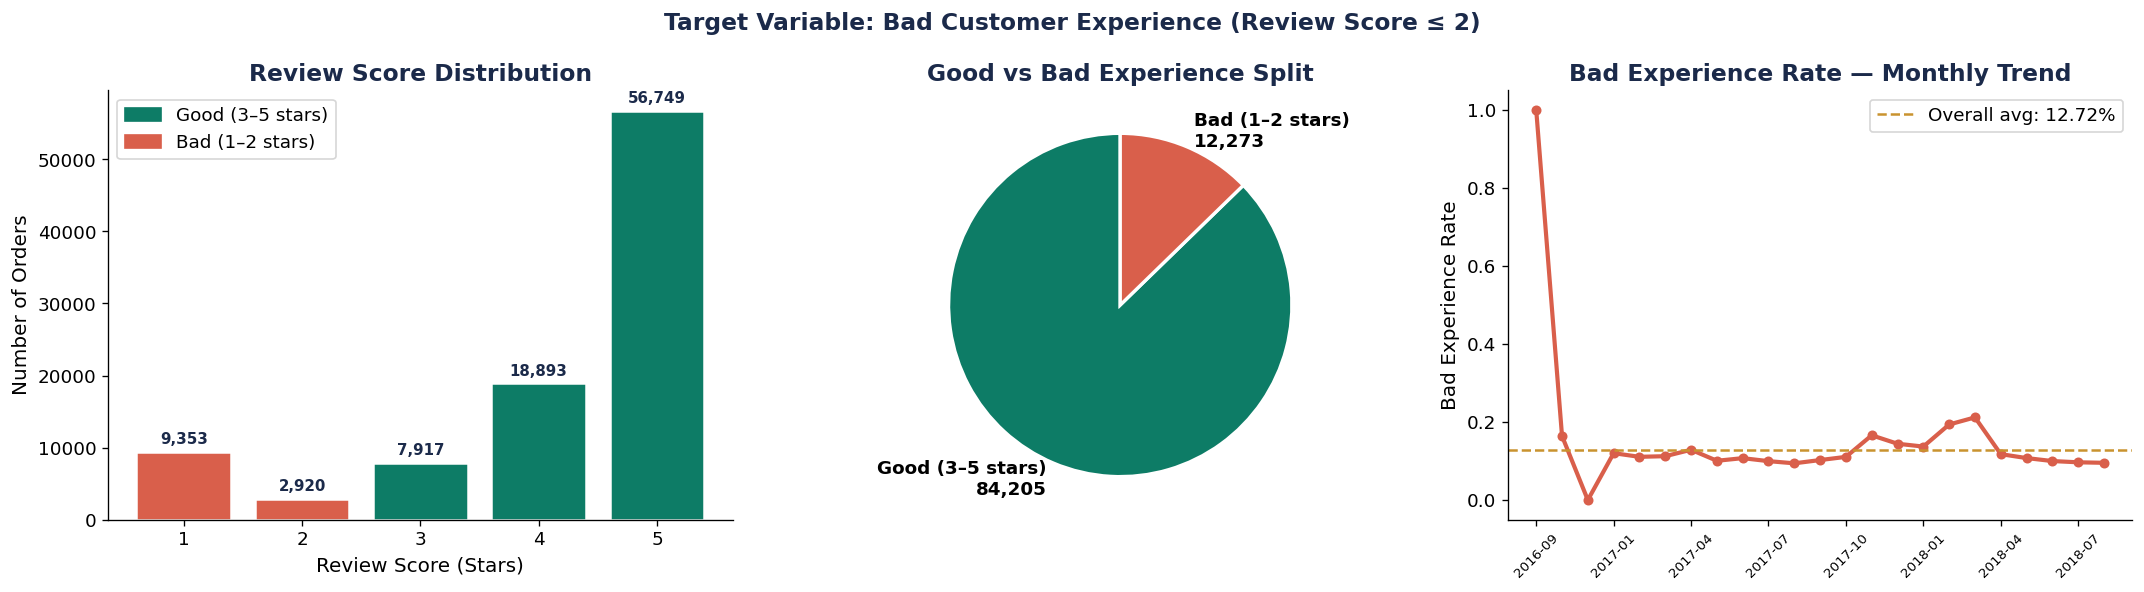

In [7]:
# ── Visualise target variable ──
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Score distribution bar chart
score_counts = delivered['review_score'].value_counts().sort_index()
colors = [CORAL if s <= 2 else TEAL for s in score_counts.index]
axes[0].bar([str(int(s)) for s in score_counts.index], score_counts.values,
            color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_title('Review Score Distribution', color=NAVY, fontweight='bold')
axes[0].set_xlabel('Review Score (Stars)')
axes[0].set_ylabel('Number of Orders')
for i, (s, c) in enumerate(score_counts.items()):
    axes[0].text(i, c + (score_counts.max() * 0.02), f'{c:,}',
                 ha='center', fontsize=9, color=NAVY, fontweight='bold')
from matplotlib.patches import Patch
axes[0].legend(handles=[Patch(color=TEAL, label='Good (3–5 stars)'),
                         Patch(color=CORAL, label='Bad (1–2 stars)')])

# Plot 2: Good vs Bad pie
bad_counts = delivered['bad_experience'].value_counts()
axes[1].pie(
    [bad_counts.get(0, 0), bad_counts.get(1, 0)],
    labels=[f'Good (3–5 stars)\n{bad_counts.get(0, 0):,}',
            f'Bad (1–2 stars)\n{bad_counts.get(1, 0):,}'],
    colors=[TEAL, CORAL], startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2},
    textprops={'fontsize': 11, 'fontweight': 'bold'})
axes[1].set_title('Good vs Bad Experience Split', color=NAVY, fontweight='bold')

# Plot 3: Monthly trend of bad experience rate
delivered['purchase_month'] = delivered['order_purchase_timestamp'].dt.to_period('M')
monthly = delivered.dropna(subset=['review_score']).groupby('purchase_month')['bad_experience'].mean()
monthly.index = monthly.index.astype(str)
step = max(1, len(monthly) // 6)
axes[2].plot(range(len(monthly)), monthly.values, color=CORAL, linewidth=2.5, marker='o', markersize=5)
axes[2].axhline(bad_rate, color=GOLD, linestyle='--', linewidth=1.5, label=f'Overall avg: {bad_rate:.2%}')
axes[2].set_xticks(range(0, len(monthly), step))
axes[2].set_xticklabels(list(monthly.index)[::step], rotation=45, fontsize=8)
axes[2].set_title('Bad Experience Rate — Monthly Trend', color=NAVY, fontweight='bold')
axes[2].set_ylabel('Bad Experience Rate')
axes[2].legend()

plt.suptitle('Target Variable: Bad Customer Experience (Review Score ≤ 2)', fontsize=14, color=NAVY, fontweight='bold')
plt.tight_layout()
plt.show()


<div style="background: linear-gradient(90deg, #1B2A4A, #0D7C66); padding: 14px 24px; border-radius: 8px; margin: 30px 0 12px 0;">
<h2 style="color: white; margin: 0; font-family: Georgia, serif;">Part 6: Build the Master Joined Table</h2>
<p style="color: #C9932F; margin: 4px 0 0 0; font-size: 1.05em;">One row per order — all features in one place</p>
</div>

<div style="background: #FFF3CD; border-left: 5px solid #C9932F; padding: 16px 20px; border-radius: 6px; margin: 12px 0;">
<strong style="color: #C9932F;">⚠️ Fan-out Prevention Strategy</strong><br>
<span style="color: #333;">
<code>order_items</code> and <code>payments</code> have multiple rows per order. We <strong>aggregate them first</strong> before joining to orders.
Joining them directly would multiply every order row — corrupting counts, sums, and all derived metrics.
</span>
</div>

In [8]:
# ── Step 1: Aggregate order_items to order level ──
items_agg = tables['order_items'].groupby('order_id').agg(
    n_items           = ('order_item_id', 'max'),
    total_price       = ('price', 'sum'),
    total_freight     = ('freight_value', 'sum'),
    avg_price         = ('price', 'mean'),
    n_unique_sellers  = ('seller_id', 'nunique'),
    n_unique_products = ('product_id', 'nunique'),
).reset_index()

print(f"order_items aggregated: {len(tables['order_items']):,} rows → {len(items_agg):,} order-level rows")

# ── Step 2: Aggregate payments to order level ──
pay_agg = tables['payments'].groupby('order_id').agg(
    total_payment     = ('payment_value', 'sum'),
    n_payment_methods = ('payment_sequential', 'max'),
    max_installments  = ('payment_installments', 'max'),
    payment_type      = ('payment_type', lambda x: x.mode()[0] if len(x) > 0 else 'unknown'),
).reset_index()

print(f"payments aggregated   : {len(tables['payments']):,} rows → {len(pay_agg):,} order-level rows")

# ── Step 3: Deduplicate reviews (one per order) ──
reviews_clean = (tables['reviews']
    .sort_values('review_creation_date')
    .drop_duplicates('order_id', keep='last')
    [['order_id', 'review_score']])

print(f"reviews deduplicated  : {len(tables['reviews']):,} rows → {len(reviews_clean):,} unique orders")

# ── Step 4: Add English category + physical attributes per order ──
products_enriched = tables['products'].merge(
    tables['category_translation'], on='product_category_name', how='left')
products_enriched['product_category_name_english'] = (
    products_enriched['product_category_name_english'].fillna('unknown'))

item_cat = tables['order_items'][['order_id', 'product_id']].merge(
    products_enriched[['product_id', 'product_category_name_english',
                        'product_weight_g', 'product_length_cm',
                        'product_height_cm', 'product_width_cm']],
    on='product_id', how='left')

cat_agg = item_cat.groupby('order_id').agg(
    main_category = ('product_category_name_english',
                     lambda x: x.mode()[0] if len(x) > 0 else 'unknown'),
    avg_weight_g  = ('product_weight_g', 'mean'),
).reset_index()

# ── Step 5: Build master table (delivered orders only) ──
delivered_clean = tables['orders'][tables['orders']['order_status'] == 'delivered'].copy()

master = (delivered_clean
    .merge(tables['customers'][['customer_id', 'customer_city', 'customer_state']],
           on='customer_id', how='left')
    .merge(items_agg,    on='order_id', how='left')
    .merge(pay_agg,      on='order_id', how='left')
    .merge(reviews_clean,on='order_id', how='left')
    .merge(cat_agg,      on='order_id', how='left')
)

# Define target on clean master
master['bad_experience'] = (master['review_score'] <= 2).astype(int)

print(f"\nMaster table shape : {master.shape[0]:,} rows × {master.shape[1]} columns")
print(f"Columns            : {list(master.columns)}")


order_items aggregated: 112,650 rows → 98,666 order-level rows
payments aggregated   : 103,886 rows → 99,440 order-level rows
reviews deduplicated  : 99,224 rows → 98,673 unique orders

Master table shape : 96,478 rows × 24 columns
Columns            : ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'customer_city', 'customer_state', 'n_items', 'total_price', 'total_freight', 'avg_price', 'n_unique_sellers', 'n_unique_products', 'total_payment', 'n_payment_methods', 'max_installments', 'payment_type', 'review_score', 'main_category', 'avg_weight_g', 'bad_experience']


<div style="background: linear-gradient(90deg, #1B2A4A, #0D7C66); padding: 14px 24px; border-radius: 8px; margin: 30px 0 12px 0;">
<h2 style="color: white; margin: 0; font-family: Georgia, serif;">Part 7: KPI Engineering</h2>
<p style="color: #C9932F; margin: 4px 0 0 0; font-size: 1.05em;">Deriving business-meaningful metrics from raw columns</p>
</div>

In [9]:
# ── Delivery timing metrics ──
master['delivery_delay_days'] = (
    (master['order_delivered_customer_date'] - master['order_estimated_delivery_date'])
    .dt.total_seconds() / 86400
).round(1)
# Positive = arrived LATE, Negative = arrived EARLY

master['actual_delivery_days'] = (
    (master['order_delivered_customer_date'] - master['order_purchase_timestamp'])
    .dt.total_seconds() / 86400
).round(1)
# Total calendar days from purchase click to parcel at door

master['approval_time_hours'] = (
    (master['order_approved_at'] - master['order_purchase_timestamp'])
    .dt.total_seconds() / 3600
).round(1)
# Hours from order placed to payment approved

master['is_late'] = (master['delivery_delay_days'] > 0).astype(int)

# ── Financial ratios ──
# Guard against division by zero for orders with missing item data
master['freight_ratio'] = np.where(
    master['total_price'] > 0,
    (master['total_freight'] / master['total_price']).round(3),
    np.nan
)
master['total_order_value'] = (master['total_price'] + master['total_freight']).round(2)

master['avg_item_value'] = np.where(
    master['n_items'] > 0,
    (master['total_price'] / master['n_items']).round(2),
    np.nan
)

# ── Purchase timing features ──
master['purchase_hour']      = master['order_purchase_timestamp'].dt.hour
master['purchase_dayofweek'] = master['order_purchase_timestamp'].dt.dayofweek  # 0 = Monday
master['purchase_month']     = master['order_purchase_timestamp'].dt.month

# ── KPI summary ──
kpi_cols = ['delivery_delay_days', 'actual_delivery_days', 'approval_time_hours',
            'is_late', 'freight_ratio', 'total_order_value', 'avg_item_value',
            'bad_experience', 'purchase_hour']

print("KPI Summary (delivered orders):")
print(master[kpi_cols].describe().T.round(2).to_string())


KPI Summary (delivered orders):
                         count   mean    std     min    25%    50%    75%       max
delivery_delay_days  96,470.00 -11.18  10.18 -146.00 -16.20 -11.90  -6.40    189.00
actual_delivery_days 96,470.00  12.56   9.55    0.50   6.80  10.20  15.70    209.60
approval_time_hours  96,464.00  10.28  20.54    0.00   0.20   0.30  14.50    741.40
is_late              96,478.00   0.08   0.27    0.00   0.00   0.00   0.00      1.00
freight_ratio        96,478.00   0.31   0.31    0.00   0.13   0.22   0.38     21.45
total_order_value    96,478.00 159.83 218.79    9.59  61.85 105.28 176.26 13,664.08
avg_item_value       96,478.00 125.23 189.70    0.85  41.91  79.00 139.90  6,735.00
bad_experience       96,478.00   0.13   0.33    0.00   0.00   0.00   0.00      1.00
purchase_hour        96,478.00  14.77   5.33    0.00  11.00  15.00  19.00     23.00


<div style="background: linear-gradient(90deg, #1B2A4A, #0D7C66); padding: 14px 24px; border-radius: 8px; margin: 30px 0 12px 0;">
<h2 style="color: white; margin: 0; font-family: Georgia, serif;">Part 8: Summary Statistics Dashboard</h2>
</div>

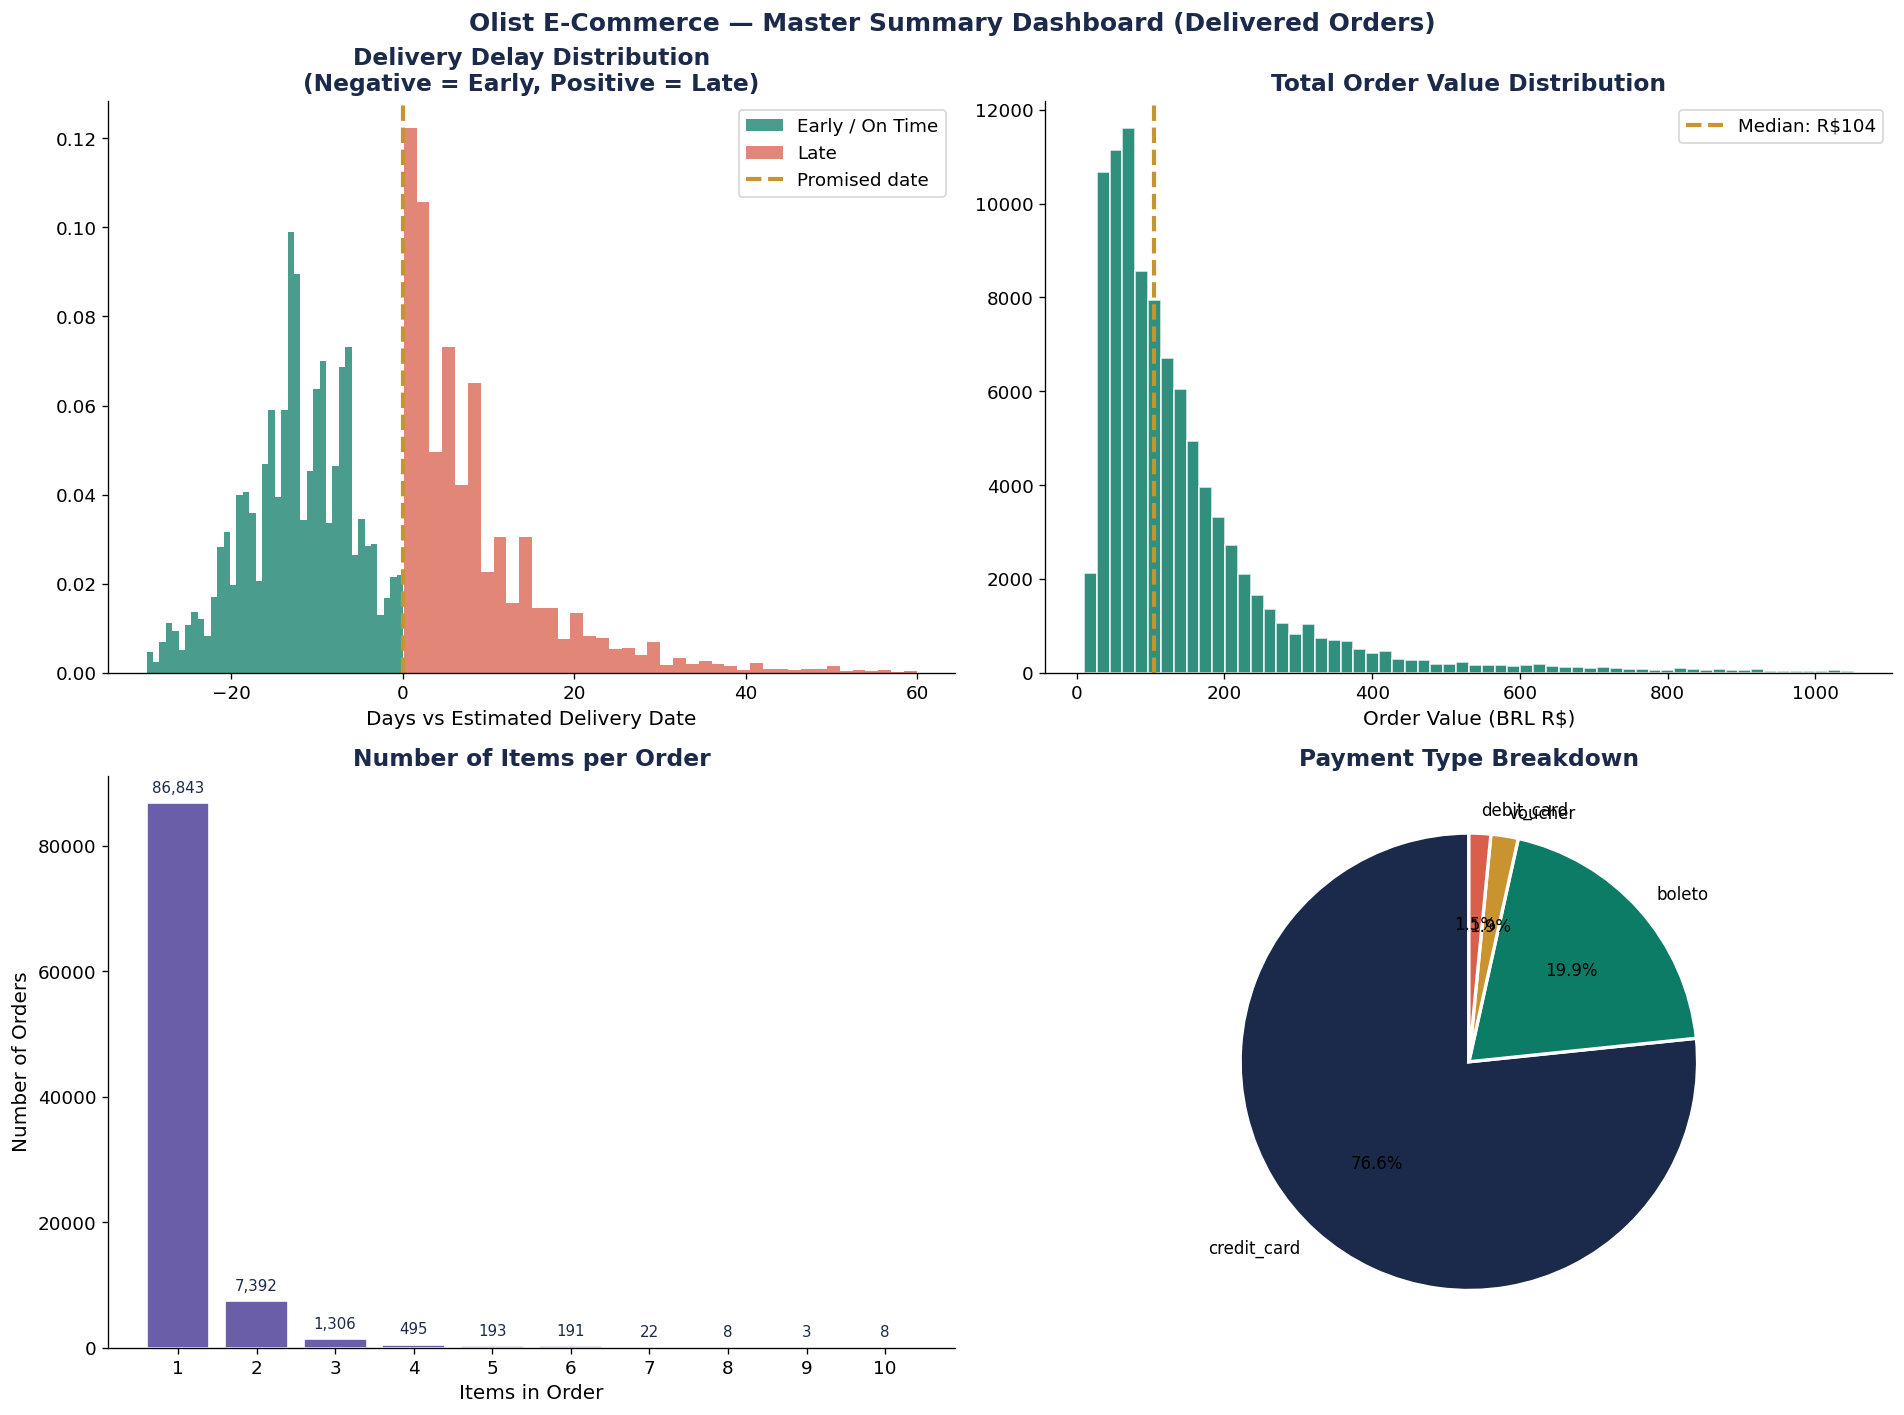


📊 Master Table At a Glance:
  Delivered orders analysed : 96,478
  Orders with review        : 95,832  (99.3%)
  Bad experience rate       : 12.72%
  Late delivery rate        : 8.05%
  Avg delivery delay        : -11.2 days
  Avg order value           : R$159.83


In [10]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# ── Plot 1: Delivery delay distribution ──
ax = axes[0, 0]
delay_clean = master['delivery_delay_days'].dropna()
delay_clean = delay_clean[(delay_clean > -30) & (delay_clean < 60)]
early = delay_clean[delay_clean <= 0]
late  = delay_clean[delay_clean > 0]
if len(early) > 0:
    ax.hist(early, bins=40, color=TEAL, alpha=0.75, label='Early / On Time', density=True)
if len(late) > 0:
    ax.hist(late, bins=40, color=CORAL, alpha=0.75, label='Late', density=True)
ax.axvline(0, color=GOLD, linewidth=2.5, linestyle='--', label='Promised date')
ax.set_title('Delivery Delay Distribution\n(Negative = Early, Positive = Late)', color=NAVY, fontweight='bold')
ax.set_xlabel('Days vs Estimated Delivery Date')
ax.legend()

# ── Plot 2: Order value distribution ──
ax = axes[0, 1]
val_clean = master['total_order_value'].dropna()
p99 = val_clean.quantile(0.99)
val_clean = val_clean[val_clean < p99]
ax.hist(val_clean, bins=60, color=TEAL, edgecolor='white', alpha=0.85)
ax.axvline(val_clean.median(), color=GOLD, linewidth=2.5, linestyle='--',
           label=f'Median: R${val_clean.median():.0f}')
ax.set_title('Total Order Value Distribution', color=NAVY, fontweight='bold')
ax.set_xlabel('Order Value (BRL R$)')
ax.legend()

# ── Plot 3: Items per order ──
ax = axes[1, 0]
item_counts = master['n_items'].value_counts().sort_index().head(10)
ax.bar(item_counts.index.astype(str), item_counts.values, color=PURPLE, edgecolor='white')
ax.set_title('Number of Items per Order', color=NAVY, fontweight='bold')
ax.set_xlabel('Items in Order')
ax.set_ylabel('Number of Orders')
for i, (idx, val) in enumerate(item_counts.items()):
    ax.text(i, val + (item_counts.max() * 0.02), f'{val:,}',
            ha='center', fontsize=9, color=NAVY)

# ── Plot 4: Payment type breakdown ──
ax = axes[1, 1]
pay_counts = master['payment_type'].dropna().value_counts()
colors_pie  = [NAVY, TEAL, GOLD, CORAL, PURPLE]
ax.pie(pay_counts.values,
       labels=pay_counts.index,
       colors=colors_pie[:len(pay_counts)],
       startangle=90,
       wedgeprops={'edgecolor': 'white', 'linewidth': 2},
       autopct='%1.1f%%',
       textprops={'fontsize': 10})
ax.set_title('Payment Type Breakdown', color=NAVY, fontweight='bold')

plt.suptitle('Olist E-Commerce — Master Summary Dashboard (Delivered Orders)',
             fontsize=15, color=NAVY, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n📊 Master Table At a Glance:")
print(f"  Delivered orders analysed : {len(master):,}")
print(f"  Orders with review        : {master['review_score'].notna().sum():,}"
      f"  ({master['review_score'].notna().mean():.1%})")
print(f"  Bad experience rate       : {master['bad_experience'].mean():.2%}")
print(f"  Late delivery rate        : {master['is_late'].mean():.2%}")
print(f"  Avg delivery delay        : {master['delivery_delay_days'].mean():.1f} days")
print(f"  Avg order value           : R${master['total_order_value'].mean():,.2f}")


In [11]:
# ── Save master table for all subsequent notebooks ──
out_path = os.path.join(DATA_DIR, 'olist_master.csv')
master.to_csv(out_path, index=False)
print(f"✅ Master table saved → {out_path}")
print(f"   Shape: {master.shape[0]:,} rows × {master.shape[1]} columns")
print(f"   Columns saved: {list(master.columns)}")


✅ Master table saved → C:\Users\DevA\OneDrive\Desktop\All in one - Desktop Files\MBA\Q8\AI ML\Dataset 3\olist_master.csv
   Shape: 96,478 rows × 34 columns
   Columns saved: ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'customer_city', 'customer_state', 'n_items', 'total_price', 'total_freight', 'avg_price', 'n_unique_sellers', 'n_unique_products', 'total_payment', 'n_payment_methods', 'max_installments', 'payment_type', 'review_score', 'main_category', 'avg_weight_g', 'bad_experience', 'delivery_delay_days', 'actual_delivery_days', 'approval_time_hours', 'is_late', 'freight_ratio', 'total_order_value', 'avg_item_value', 'purchase_hour', 'purchase_dayofweek', 'purchase_month']


<div style="background: linear-gradient(90deg, #E0F4EF, #FDF6E8); border-left: 5px solid #0D7C66; border-right: 5px solid #C9932F; padding: 16px 20px; border-radius: 6px; margin: 20px 0;">
<strong style="color: #1B2A4A;">✅ Notebook 1 Complete — What We Now Know</strong>
<ul style="color: #333; font-size: 1.05em; line-height: 1.8; margin-top: 8px;">
<li>The dataset covers <strong>~99K delivered orders</strong> across Brazil from 2016–2018.</li>
<li>Our target is <strong>bad_experience</strong> (review ≤ 2 stars) — ~11% rate, so the data is class-imbalanced.</li>
<li>We built a clean master table with <strong>one row per order</strong> by aggregating items and payments first.</li>
<li>Key engineered KPIs: <code>delivery_delay_days</code>, <code>is_late</code>, <code>freight_ratio</code>, <code>total_order_value</code>, <code>actual_delivery_days</code>.</li>
<li>The master table is saved as <code>olist_master.csv</code> and ready for deep analysis.</li>
</ul>
</div>

**→ Next: Notebook 2 — Data Deep Dive (Bivariate Analysis & Feature–Target Relationships)**
